# PX4 Phase 1 Rate Dynamics PINN Training v2

Train the multi-run nominal local dynamics model from the processed PX4 Standard VTOL rate/thrust dataset.

This version is intended for the `px4_dataset_builder_v2` output:

- `train.csv`
- `val.csv`
- `test.csv`
- `metadata.json`

Model contract:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```

The model predicts one-step state deltas. Rollout checks then apply predicted deltas recursively with the logged action sequence.

Compared with v1:

- searches for `px4_phase1_rate_dynamics_dataset_v2_multirun_*` first
- uses a larger GPU-friendly MLP
- trains longer with early stopping
- saves a v2 checkpoint contract for later MPC experiments


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Option A: set this manually after copying the processed folder into Drive.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/PX4_Datasets/px4_phase1_rate_dynamics_dataset_v2_multirun_20260506_190000'

# Option B: automatically search common locations.
def find_latest_dataset_dir():
    patterns = [
        '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        '/content/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        './px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
    ]
    matches = []
    import glob
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches = sorted(set(matches))
    matches = [Path(m) for m in matches if (Path(m) / 'train.csv').exists()]
    if not matches:
        raise FileNotFoundError(
            'No processed dataset found. Set DATASET_DIR to the folder containing train.csv/val.csv/test.csv.'
        )
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load processed CSVs
train_df = pd.read_csv(DATASET_PATH / 'train.csv')
val_df = pd.read_csv(DATASET_PATH / 'val.csv')
test_df = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([train_df, val_df, test_df], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in train_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in train_df.columns if c.startswith('u_')]

feature_cols = (
    [f'x_{c}' for c in state_cols]
    + [f'u_{c}' for c in action_cols]
    + [f'prev_u_{c}' for c in action_cols]
    + [f'du_{c}' for c in action_cols]
    + ['dt_s']
)
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]

missing = [c for c in feature_cols + target_cols for df in [train_df] if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('n_features:', len(feature_cols), 'n_targets:', len(target_cols))

display(pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
}))

if 'scenario' in train_df.columns:
    display(pd.concat([
        train_df.assign(split='train'),
        val_df.assign(split='val'),
        test_df.assign(split='test'),
    ]).groupby(['split', 'scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 4386 1699 1838
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
n_features: 23 n_targets: 10


,split,rows
0,train,4386
1,val,1699
2,test,1838


,split,scenario,rows
0,test,N00_hover_hold_0p5192,83
1,test,N01_pitch_rate_doublet_5dps,73
2,test,N02_pitch_rate_doublet_10dps,111
3,test,N03_roll_rate_doublet_5dps,44
4,test,N04_roll_rate_doublet_10dps,95
5,test,N05_yaw_rate_doublet_10dps,104
6,test,N06_yaw_rate_doublet_20dps,92
7,test,N07_thrust_step_pm010,103
8,test,N08_thrust_step_pm020,118
9,test,N09_pitch_thrust_coupled,116


,target,split,mean,std,min,max
0,dx_relative_altitude_m,train,-0.014824,0.039513,-1.702000,0.042000
1,dx_vel_north_m_s,train,-0.000306,0.005642,-0.060000,0.100000
2,dx_vel_east_m_s,train,-0.003456,0.054870,-3.520000,0.080000
3,dx_vel_down_m_s,train,0.001167,0.008749,-0.070000,0.390000
4,dx_roll_deg,train,-0.000336,0.037214,-0.726146,0.619929
5,dx_pitch_deg,train,0.002372,0.195356,-0.648688,12.628178
6,dx_yaw_deg,train,-0.003822,0.122907,-6.195786,1.032578
7,dx_roll_rate_rad_s,train,-0.000017,0.003323,-0.105426,0.102651
8,dx_pitch_rate_rad_s,train,0.000027,0.003904,-0.111722,0.109920
9,dx_yaw_rate_rad_s,train,0.000018,0.002670,-0.042038,0.041572


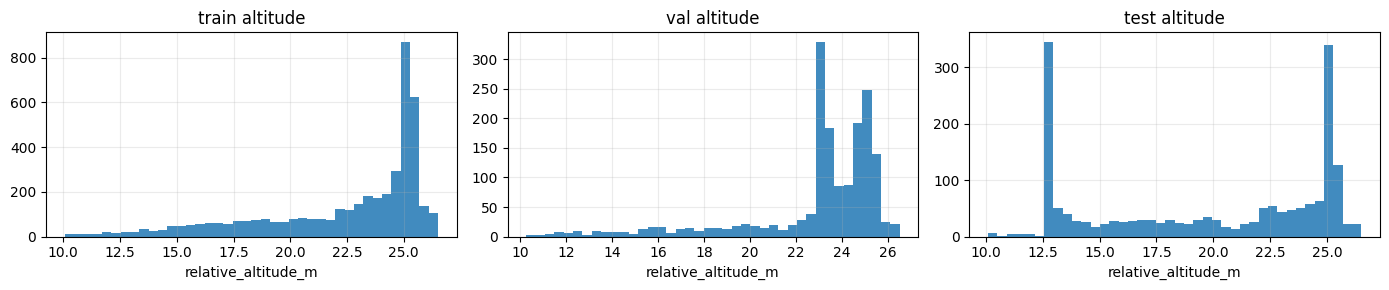

In [4]:
# Basic data sanity
def describe_targets(df, name):
    desc = df[target_cols].agg(['mean', 'std', 'min', 'max']).T
    desc.insert(0, 'split', name)
    return desc.reset_index().rename(columns={'index': 'target'})

display(pd.concat([
    describe_targets(train_df, 'train'),
    describe_targets(val_df, 'val'),
    describe_targets(test_df, 'test'),
], ignore_index=True))

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ['train', 'val', 'test']):
    ax.hist(df['x_relative_altitude_m'], bins=40, alpha=0.85)
    ax.set_title(f'{title} altitude')
    ax.set_xlabel('relative_altitude_m')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
# Scaling and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)

    @classmethod
    def fit(cls, arr):
        return cls(np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))

    def transform(self, arr):
        return (np.asarray(arr, dtype=np.float32) - self.mean) / self.std

    def inverse_transform(self, arr):
        return np.asarray(arr, dtype=np.float32) * self.std + self.mean

    def to_dict(self, columns):
        return {'columns': list(columns), 'mean': self.mean.tolist(), 'std': self.std.tolist()}

X_train_raw = train_df[feature_cols].to_numpy(np.float32)
Y_train_raw = train_df[target_cols].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].to_numpy(np.float32)
Y_val_raw = val_df[target_cols].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].to_numpy(np.float32)
Y_test_raw = test_df[target_cols].to_numpy(np.float32)

x_scaler = StandardScaler.fit(X_train_raw)
y_scaler = StandardScaler.fit(Y_train_raw)

X_train = x_scaler.transform(X_train_raw)
Y_train = y_scaler.transform(Y_train_raw)
X_val = x_scaler.transform(X_val_raw)
Y_val = y_scaler.transform(Y_val_raw)
X_test = x_scaler.transform(X_test_raw)
Y_test = y_scaler.transform(Y_test_raw)

BATCH_SIZE = 512
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(Y_val)),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
print('batches:', len(train_loader), len(val_loader))


batches: 9 4


In [6]:
# Model
class RateDynamicsMLP(nn.Module):
    def __init__(self, n_in, n_out, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(depth):
            layers += [nn.Linear(last, hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = hidden
        layers.append(nn.Linear(last, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

MODEL_CONFIG = dict(hidden=512, depth=5, dropout=0.02)
model = RateDynamicsMLP(len(feature_cols), len(target_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


RateDynamicsMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): Linear(in_features=512, out_features=1

epoch=001 train=0.453653 val=0.160178 best=0.160178@1 lr=1.50e-03
epoch=020 train=0.073559 val=0.096528 best=0.088995@9 lr=1.50e-03
epoch=040 train=0.063043 val=0.088128 best=0.083350@39 lr=1.49e-03
epoch=060 train=0.059610 val=0.084380 best=0.080538@55 lr=1.47e-03
epoch=080 train=0.058130 val=0.085791 best=0.080538@55 lr=1.45e-03
epoch=100 train=0.056375 val=0.086618 best=0.080538@55 lr=1.43e-03
epoch=120 train=0.055495 val=0.089241 best=0.080538@55 lr=1.39e-03
early stop at epoch=135, best_epoch=55
training seconds: 10.2


,epoch,train_loss,val_loss,lr
130,131,0.054033,0.090775,0.001375
131,132,0.054990,0.088866,0.001373
132,133,0.054000,0.090179,0.001371
133,134,0.054482,0.090499,0.001369
134,135,0.054216,0.091394,0.001367


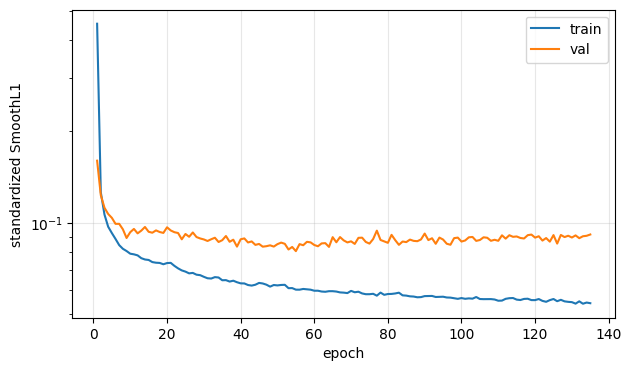

In [7]:
# Training
# Multi-run v2 has more data, so this is intentionally larger than v1.
EPOCHS = 700
LR = 1.5e-3
WEIGHT_DECAY = 2e-5
PATIENCE = 80
GRAD_CLIP = 2.0

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
loss_fn = nn.SmoothL1Loss(beta=0.5)

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        total += float(loss.detach().cpu()) * len(xb)
        n += len(xb)
    return total / max(n, 1)

best_state = None
best_val = float('inf')
best_epoch = -1
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, True)
    val_loss = run_epoch(val_loader, False)
    scheduler.step()
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'lr': scheduler.get_last_lr()[0]})
    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(f'epoch={epoch:03d} train={train_loss:.6f} val={val_loss:.6f} best={best_val:.6f}@{best_epoch} lr={scheduler.get_last_lr()[0]:.2e}')
    if epoch - best_epoch >= PATIENCE:
        print(f'early stop at epoch={epoch}, best_epoch={best_epoch}')
        break

model.load_state_dict(best_state)
print('training seconds:', round(time.time() - t0, 1))
hist_df = pd.DataFrame(history)
display(hist_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], label='train')
plt.plot(hist_df['epoch'], hist_df['val_loss'], label='val')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('epoch')
plt.ylabel('standardized SmoothL1')
plt.show()


In [8]:
# One-step metrics in physical units
@torch.no_grad()
def predict_dx(df):
    x = x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    preds = []
    model.eval()
    for i in range(0, len(x), 4096):
        xb = torch.tensor(x[i:i+4096], dtype=torch.float32, device=device)
        pred_scaled = model(xb).detach().cpu().numpy()
        preds.append(pred_scaled)
    pred_scaled = np.concatenate(preds, axis=0) if preds else np.zeros((0, len(target_cols)), dtype=np.float32)
    return y_scaler.inverse_transform(pred_scaled)

def one_step_metrics(df, split):
    pred = predict_dx(df)
    true = df[target_cols].to_numpy(np.float32)
    rows = []
    for j, col in enumerate(target_cols):
        err = pred[:, j] - true[:, j]
        rows.append({
            'split': split,
            'target': col,
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(true[:, j])),
        })
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    one_step_metrics(train_df, 'train'),
    one_step_metrics(val_df, 'val'),
    one_step_metrics(test_df, 'test'),
], ignore_index=True)
display(metrics_df)


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.036167,0.004821,0.039509
1,train,dx_vel_north_m_s,0.003704,0.001377,0.005641
2,train,dx_vel_east_m_s,0.053101,0.003038,0.054864
3,train,dx_vel_down_m_s,0.008028,0.002460,0.008748
4,train,dx_roll_deg,0.010017,0.001940,0.037209
5,train,dx_pitch_deg,0.186863,0.005190,0.195334
6,train,dx_yaw_deg,0.094772,0.008944,0.122893
7,train,dx_roll_rate_rad_s,0.001756,0.000338,0.003322
8,train,dx_pitch_rate_rad_s,0.001458,0.000355,0.003903
9,train,dx_yaw_rate_rad_s,0.000472,0.000282,0.002669


In [9]:
# Rollout sanity by scenario
def make_feature_row(state_vec, action_vec, prev_action_vec, dt_s):
    row = []
    row.extend(state_vec.tolist())
    row.extend(action_vec.tolist())
    row.extend(prev_action_vec.tolist())
    row.extend((action_vec - prev_action_vec).tolist())
    row.append(float(dt_s))
    return np.asarray(row, dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df, scenario, max_steps=None):
    sdf = df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None:
        sdf = sdf.iloc[:max_steps].copy()
    if len(sdf) < 2:
        return None
    true_x = sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next = sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions = sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions_logged = sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts = sdf['dt_s'].to_numpy(np.float32)

    x_pred = true_x[0].copy()
    prev_action = prev_actions_logged[0].copy()
    pred_states = []
    for k in range(len(sdf)):
        feat = make_feature_row(x_pred, actions[k], prev_action, dts[k])
        feat_scaled = x_scaler.transform(feat[None, :])
        dx_scaled = model(torch.tensor(feat_scaled, dtype=torch.float32, device=device)).cpu().numpy()
        dx = y_scaler.inverse_transform(dx_scaled)[0]
        x_pred = x_pred + dx
        pred_states.append(x_pred.copy())
        prev_action = actions[k].copy()
    pred_states = np.asarray(pred_states)
    err = pred_states - true_next
    rows = []
    for j, col in enumerate(state_cols):
        rows.append({
            'scenario': scenario,
            'state': col,
            'rollout_rmse': float(np.sqrt(np.mean(err[:, j] ** 2))),
            'rollout_max_abs': float(np.max(np.abs(err[:, j]))),
            'steps': int(len(sdf)),
        })
    return pd.DataFrame(rows), sdf, pred_states, true_next

scenario_metrics = []
for scenario in sorted(test_df['scenario'].unique()):
    result = rollout_scenario(test_df, scenario)
    if result is None:
        continue
    m, _, _, _ = result
    scenario_metrics.append(m)
rollout_metrics_df = pd.concat(scenario_metrics, ignore_index=True)
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps
0,N00_hover_hold_0p5192,relative_altitude_m,4.747326,11.443593,83
1,N00_hover_hold_0p5192,vel_north_m_s,0.074932,0.109519,83
2,N00_hover_hold_0p5192,vel_east_m_s,0.290512,0.508160,83
3,N00_hover_hold_0p5192,vel_down_m_s,0.525998,0.885912,83
4,N00_hover_hold_0p5192,roll_deg,0.093359,0.209309,83
...,...,...,...,...,...
105,N11_mixed_sequence,pitch_deg,2.420672,4.811597,899
106,N11_mixed_sequence,yaw_deg,8.142922,13.842552,899
107,N11_mixed_sequence,roll_rate_rad_s,0.009774,0.049086,899
108,N11_mixed_sequence,pitch_rate_rad_s,0.012388,0.059333,899


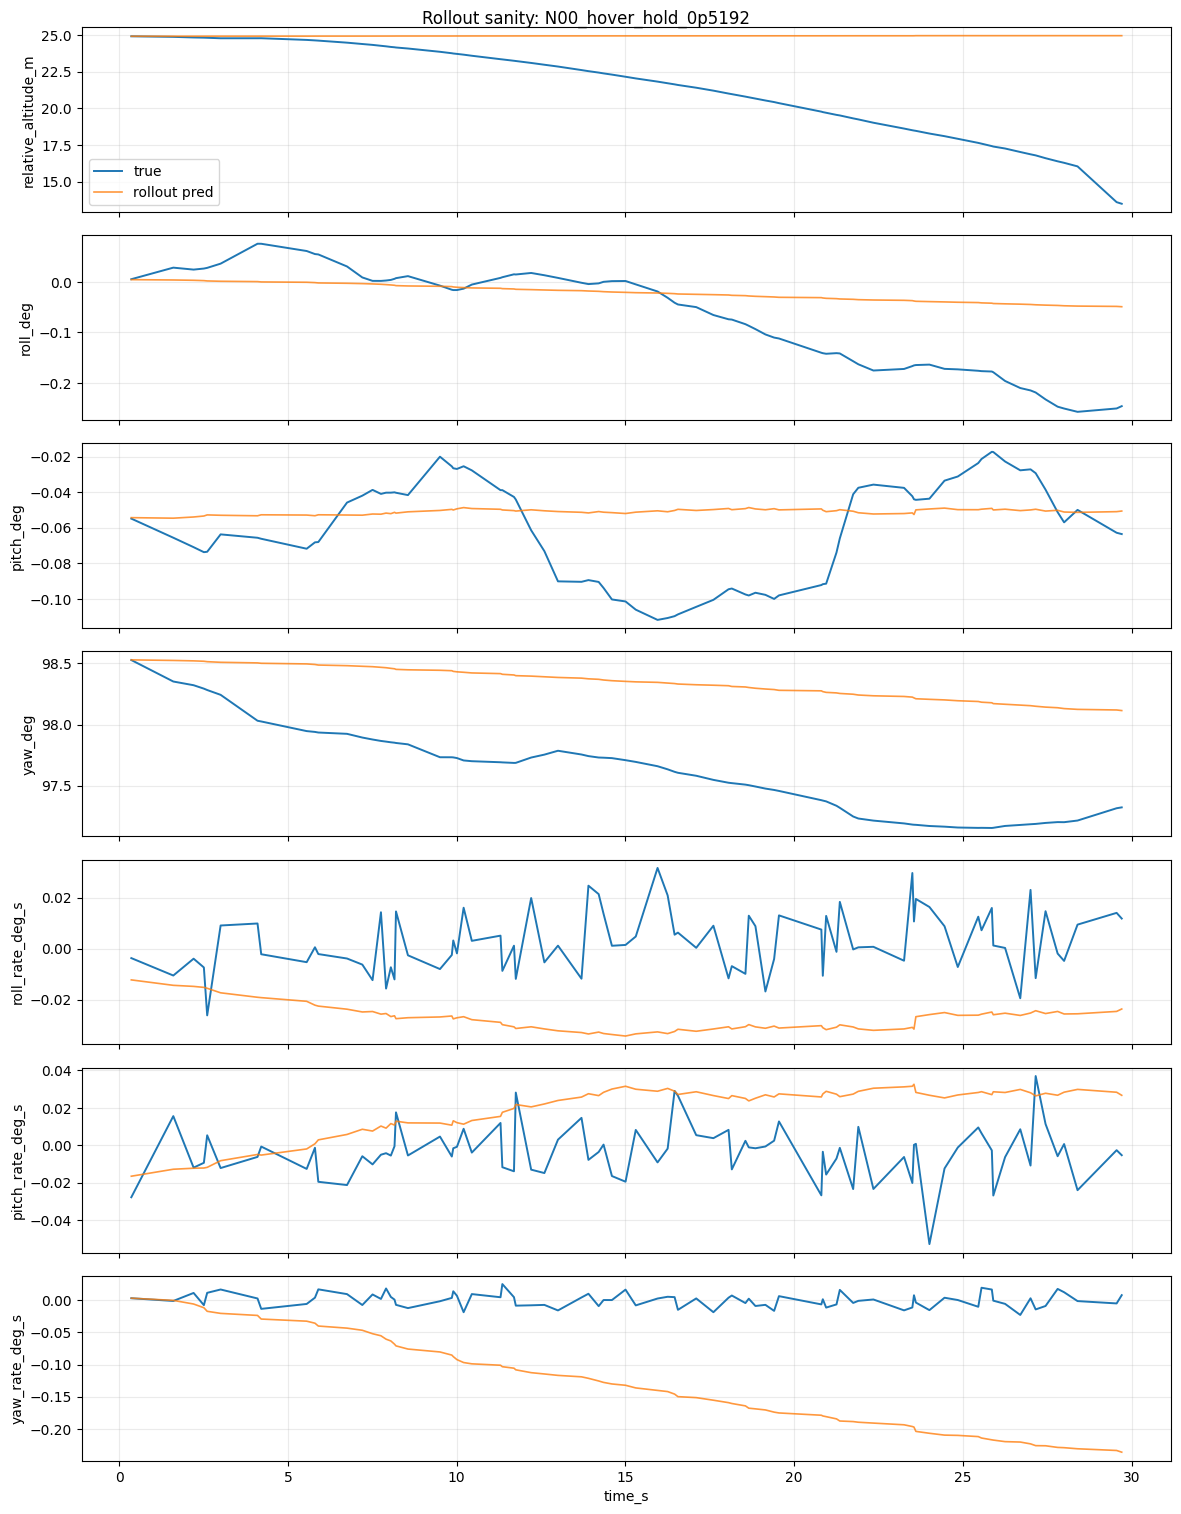

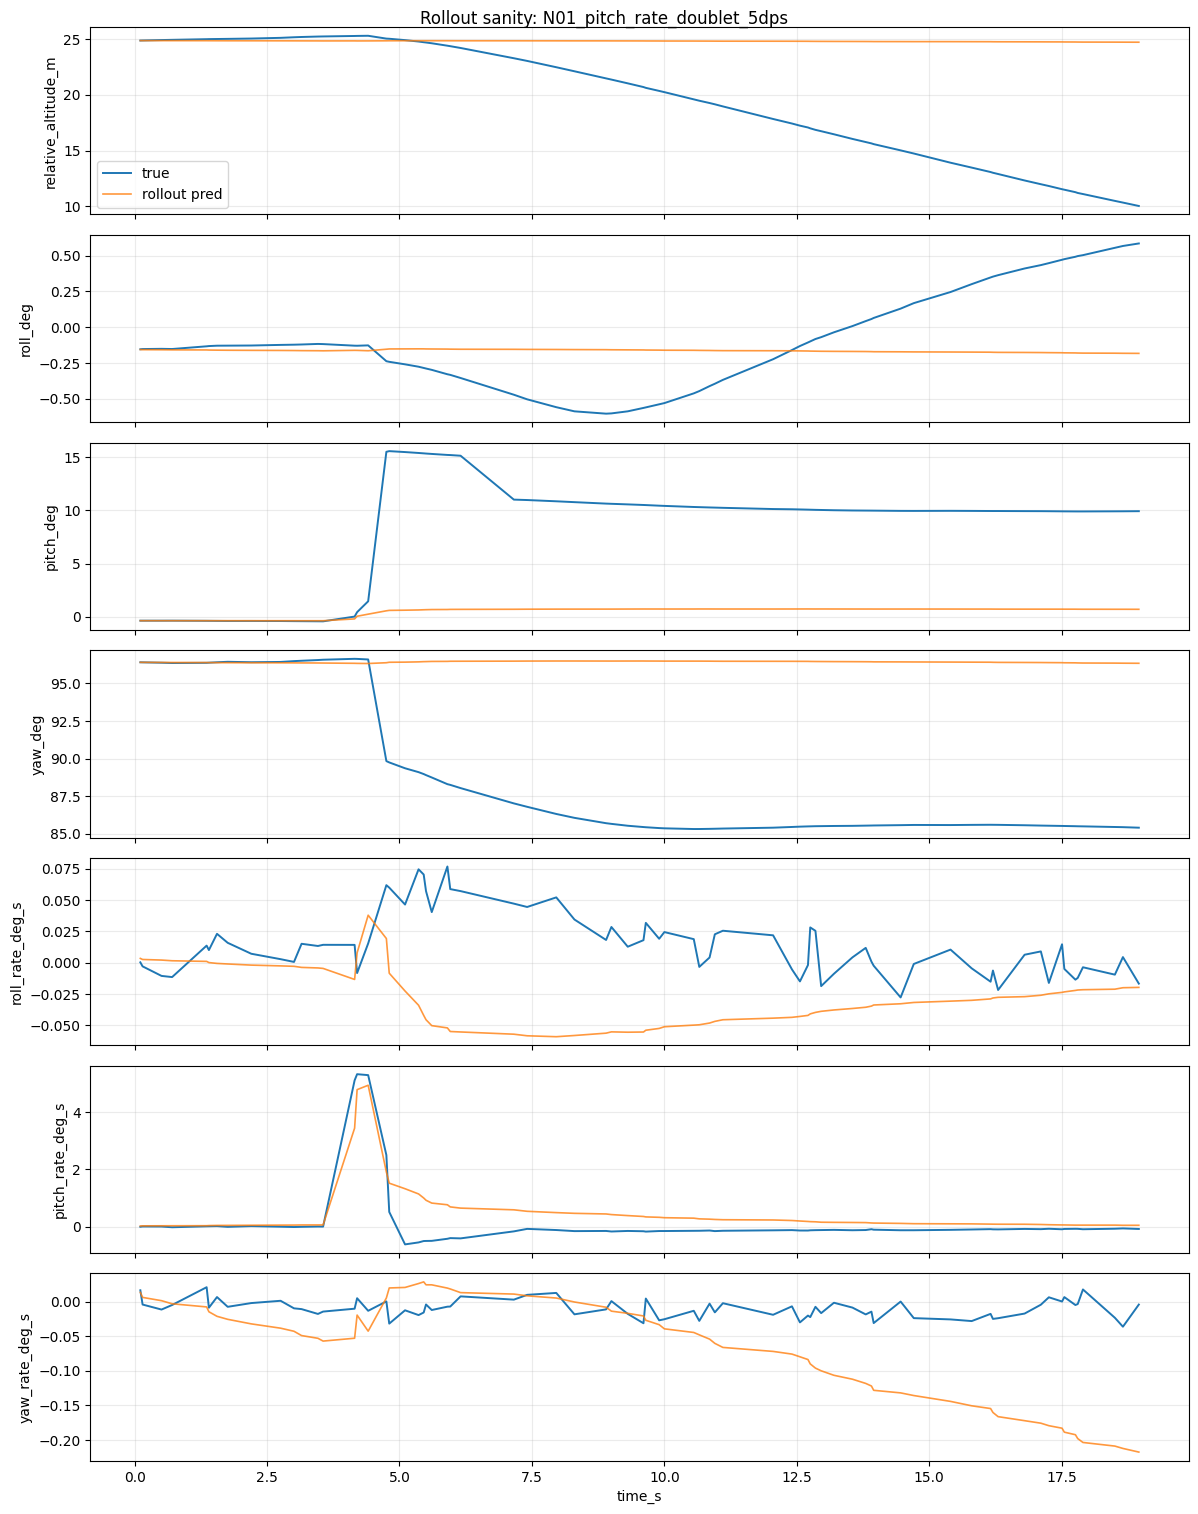

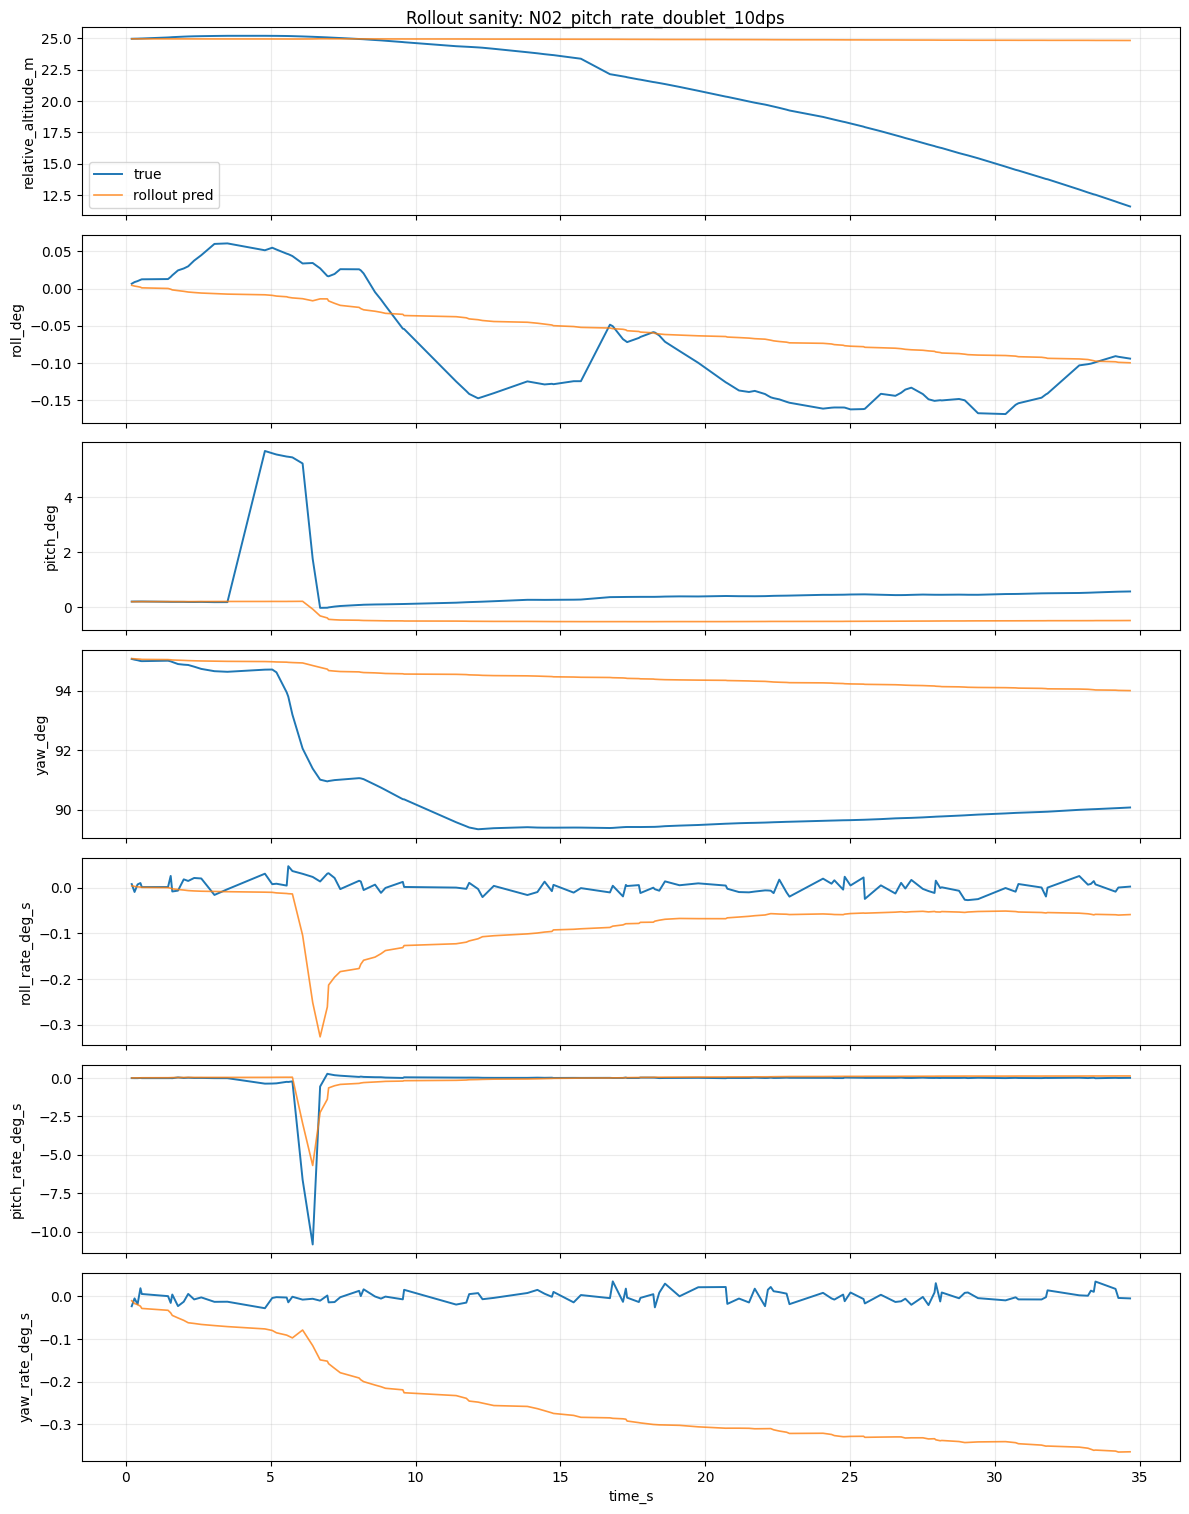

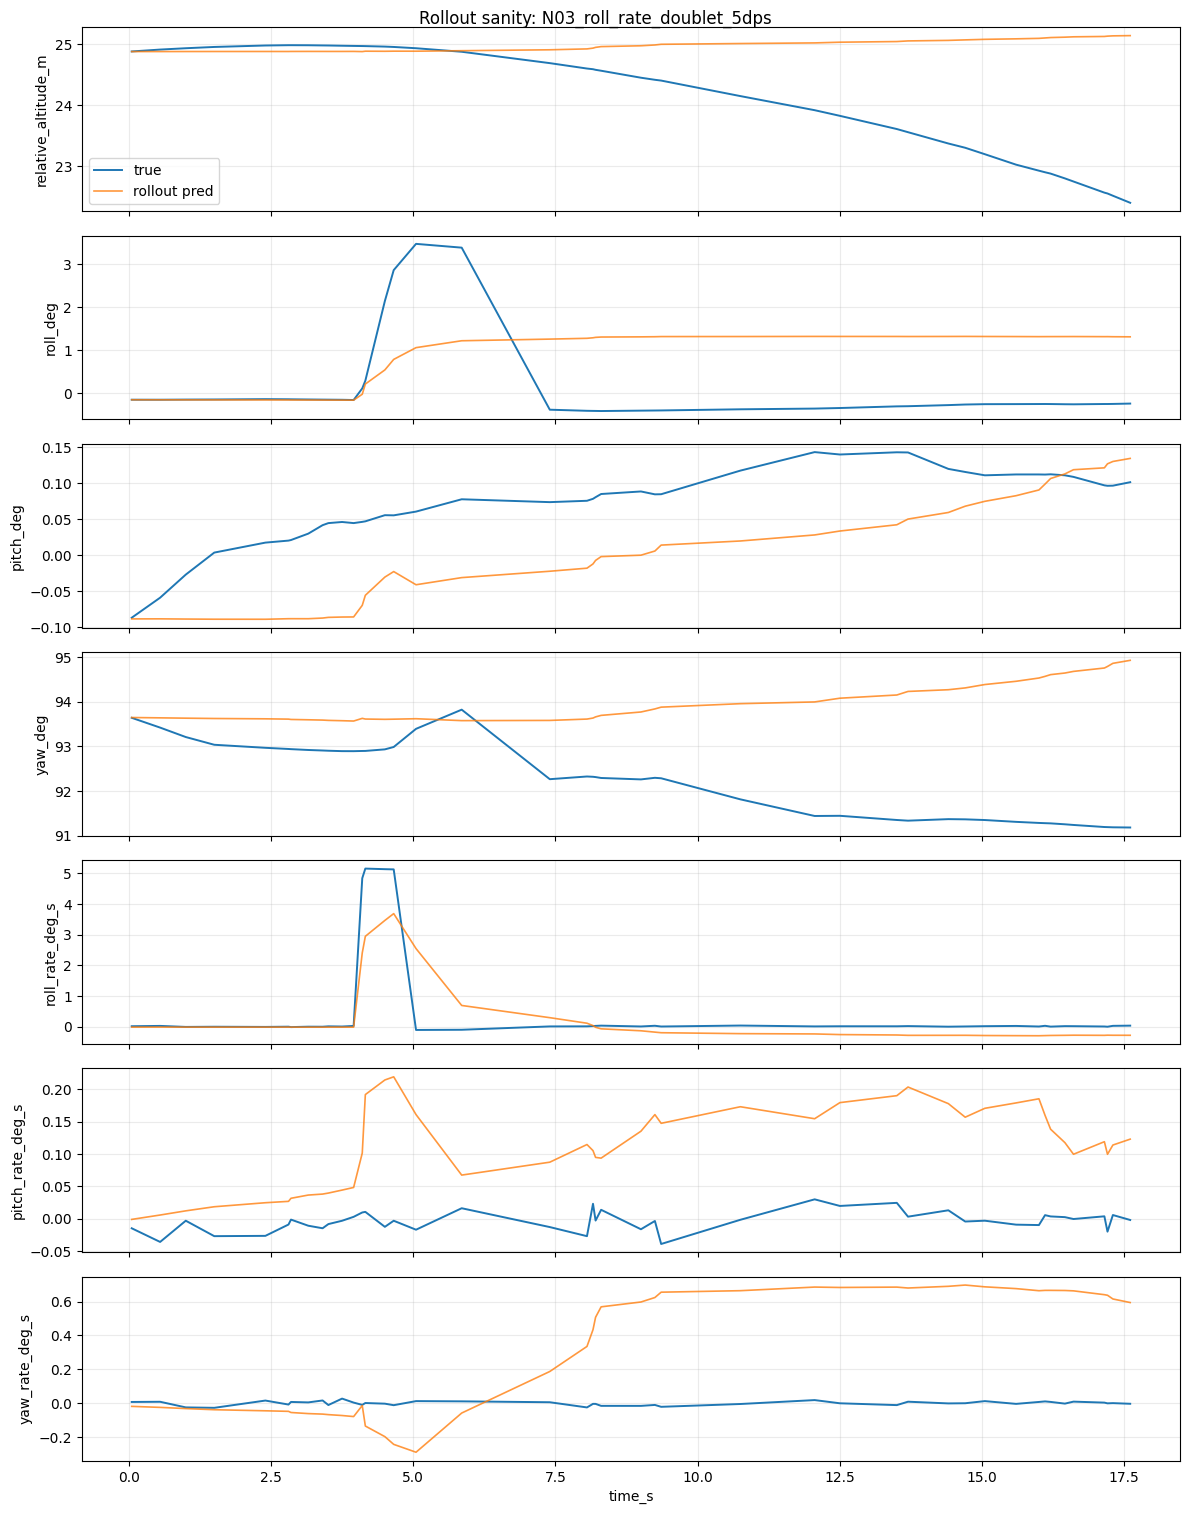

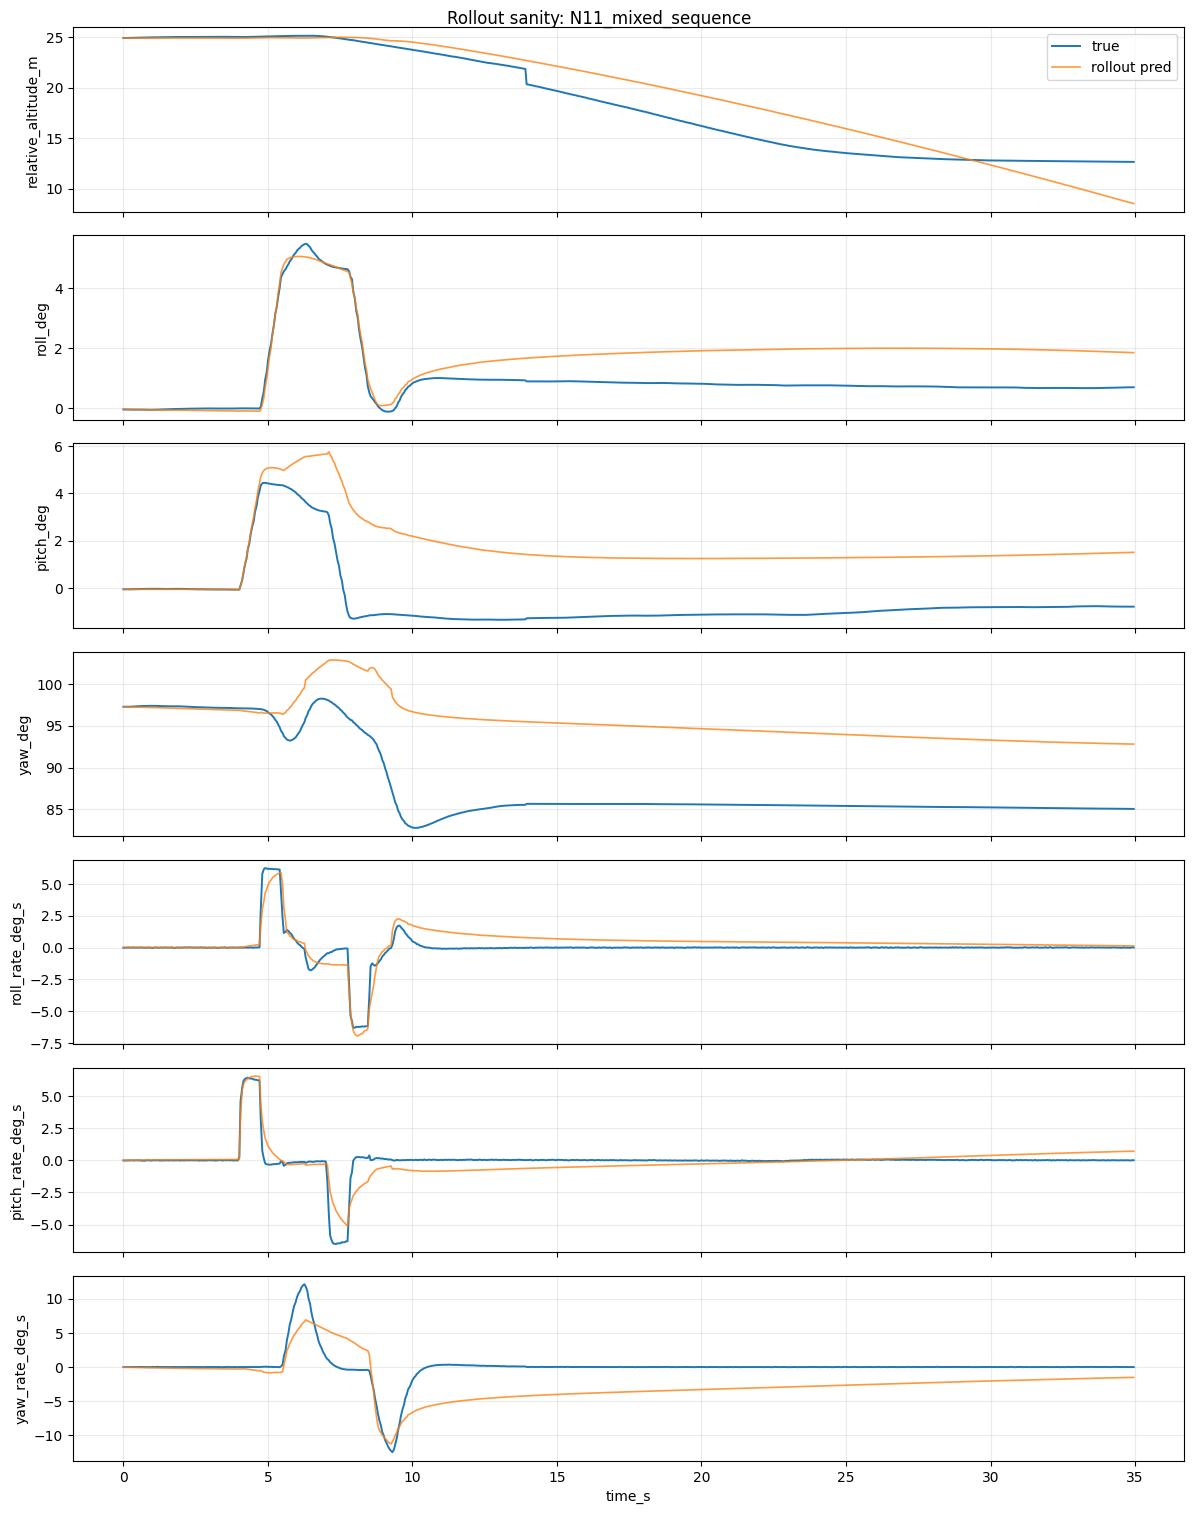

In [10]:
# Plot selected rollout scenarios
def plot_rollout(df, scenario, max_steps=500):
    result = rollout_scenario(df, scenario, max_steps=max_steps)
    if result is None:
        print('not enough rows for', scenario)
        return
    _, sdf, pred_states, true_next = result
    t = sdf['time_s'].to_numpy()
    plot_states = ['relative_altitude_m', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
    n = len(plot_states)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.2 * n), sharex=True)
    for ax, state in zip(axes, plot_states):
        if state not in state_cols:
            continue
        j = state_cols.index(state)
        y_true = true_next[:, j]
        y_pred = pred_states[:, j]
        if state.endswith('_rad_s'):
            y_true = np.rad2deg(y_true)
            y_pred = np.rad2deg(y_pred)
            label = state.replace('_rad_s', '_deg_s')
        else:
            label = state
        ax.plot(t, y_true, label='true', lw=1.4)
        ax.plot(t, y_pred, label='rollout pred', lw=1.2, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[-1].set_xlabel('time_s')
    fig.suptitle(f'Rollout sanity: {scenario}')
    plt.tight_layout()
    plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]:
    plot_rollout(test_df, scenario, max_steps=500)

if 'N11_mixed_sequence' in set(test_df['scenario']):
    plot_rollout(test_df, 'N11_mixed_sequence', max_steps=700)


In [11]:
# Save checkpoint for future MPC experiments
SAVE_ROOT = Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH / 'models'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
stamp = time.strftime('%Y%m%d_%H%M%S')
ckpt_path = SAVE_ROOT / f'px4_phase1_rate_dynamics_mlp_v2_{stamp}.pt'

checkpoint = {
    'model_version': 'px4_phase1_rate_dynamics_mlp_v2',
    'state_dict': model.state_dict(),
    'model_config': {
        'n_in': len(feature_cols),
        'n_out': len(target_cols),
        **MODEL_CONFIG,
    },
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'state_cols': state_cols,
    'action_cols': action_cols,
    'x_scaler': x_scaler.to_dict(feature_cols),
    'y_scaler': y_scaler.to_dict(target_cols),
    'dataset_path': str(DATASET_PATH),
    'metadata': metadata,
    'history': hist_df.to_dict(orient='records'),
    'one_step_metrics': metrics_df.to_dict(orient='records'),
    'rollout_metrics': rollout_metrics_df.to_dict(orient='records'),
}
torch.save(checkpoint, ckpt_path)
print('saved:', ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v2_20260506_100622.pt


In [12]:
# Minimal load check
loaded = torch.load(ckpt_path, map_location='cpu')
print('loaded keys:', sorted(loaded.keys()))
print('feature count:', len(loaded['feature_cols']))
print('target count:', len(loaded['target_cols']))


loaded keys: ['action_cols', 'dataset_path', 'feature_cols', 'history', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature count: 23
target count: 10
